In [7]:
from epaisseur_module import get_thickness_in_time_space, get_thickness_in_time, get_thickness_in_line, get_thickness_in_point,get_datacube, calcul
import os
import matplotlib.pyplot as plt
import numpy as np
from arsf_envi_reader import envi_header
from scipy.signal import savgol_filter
import pandas as pd
import matplotlib
from scipy.ndimage import median_filter
from optifik.minmax import thickness_from_minmax
matplotlib.rcParams["text.usetex"]=True

On acquiert le spectre de la lumière réfléchie sur un film liquie mince, à l'aide d'une caméra hyperspectrale, sur une ligne spatiale et en temps.
Les données issues de la caméra consistent en un datacube contenant la valeur de l'intensité lumineuse en fonction de la longueur d'onde, du temps et de l'espace.
Ici on propose de calculer l'épaisseur du film mince en un point d'espace et de temps.


Préalable au calcul

In [8]:
# fichier
folder = r"26-10-23"
file_name_bil = '500 rpm tige 250 lendemain matin'
file_bil = os.path.join(folder, file_name_bil)

# récupération des données du header
hdr = envi_header.read_hdr_file(file_bil+'.hdr', keep_case=False) #type dictionnaire
n_temps = int(hdr['lines'])
n_espace = int(hdr['samples'])
file_bil = file_bil + ".bil"

#outliers
prop_max_outliers = 1

#détection des min et max
prominence = 100
distance = 1

#indice de réfraction huile silicone
n = 1.52045

Calcul de l'épaisseur

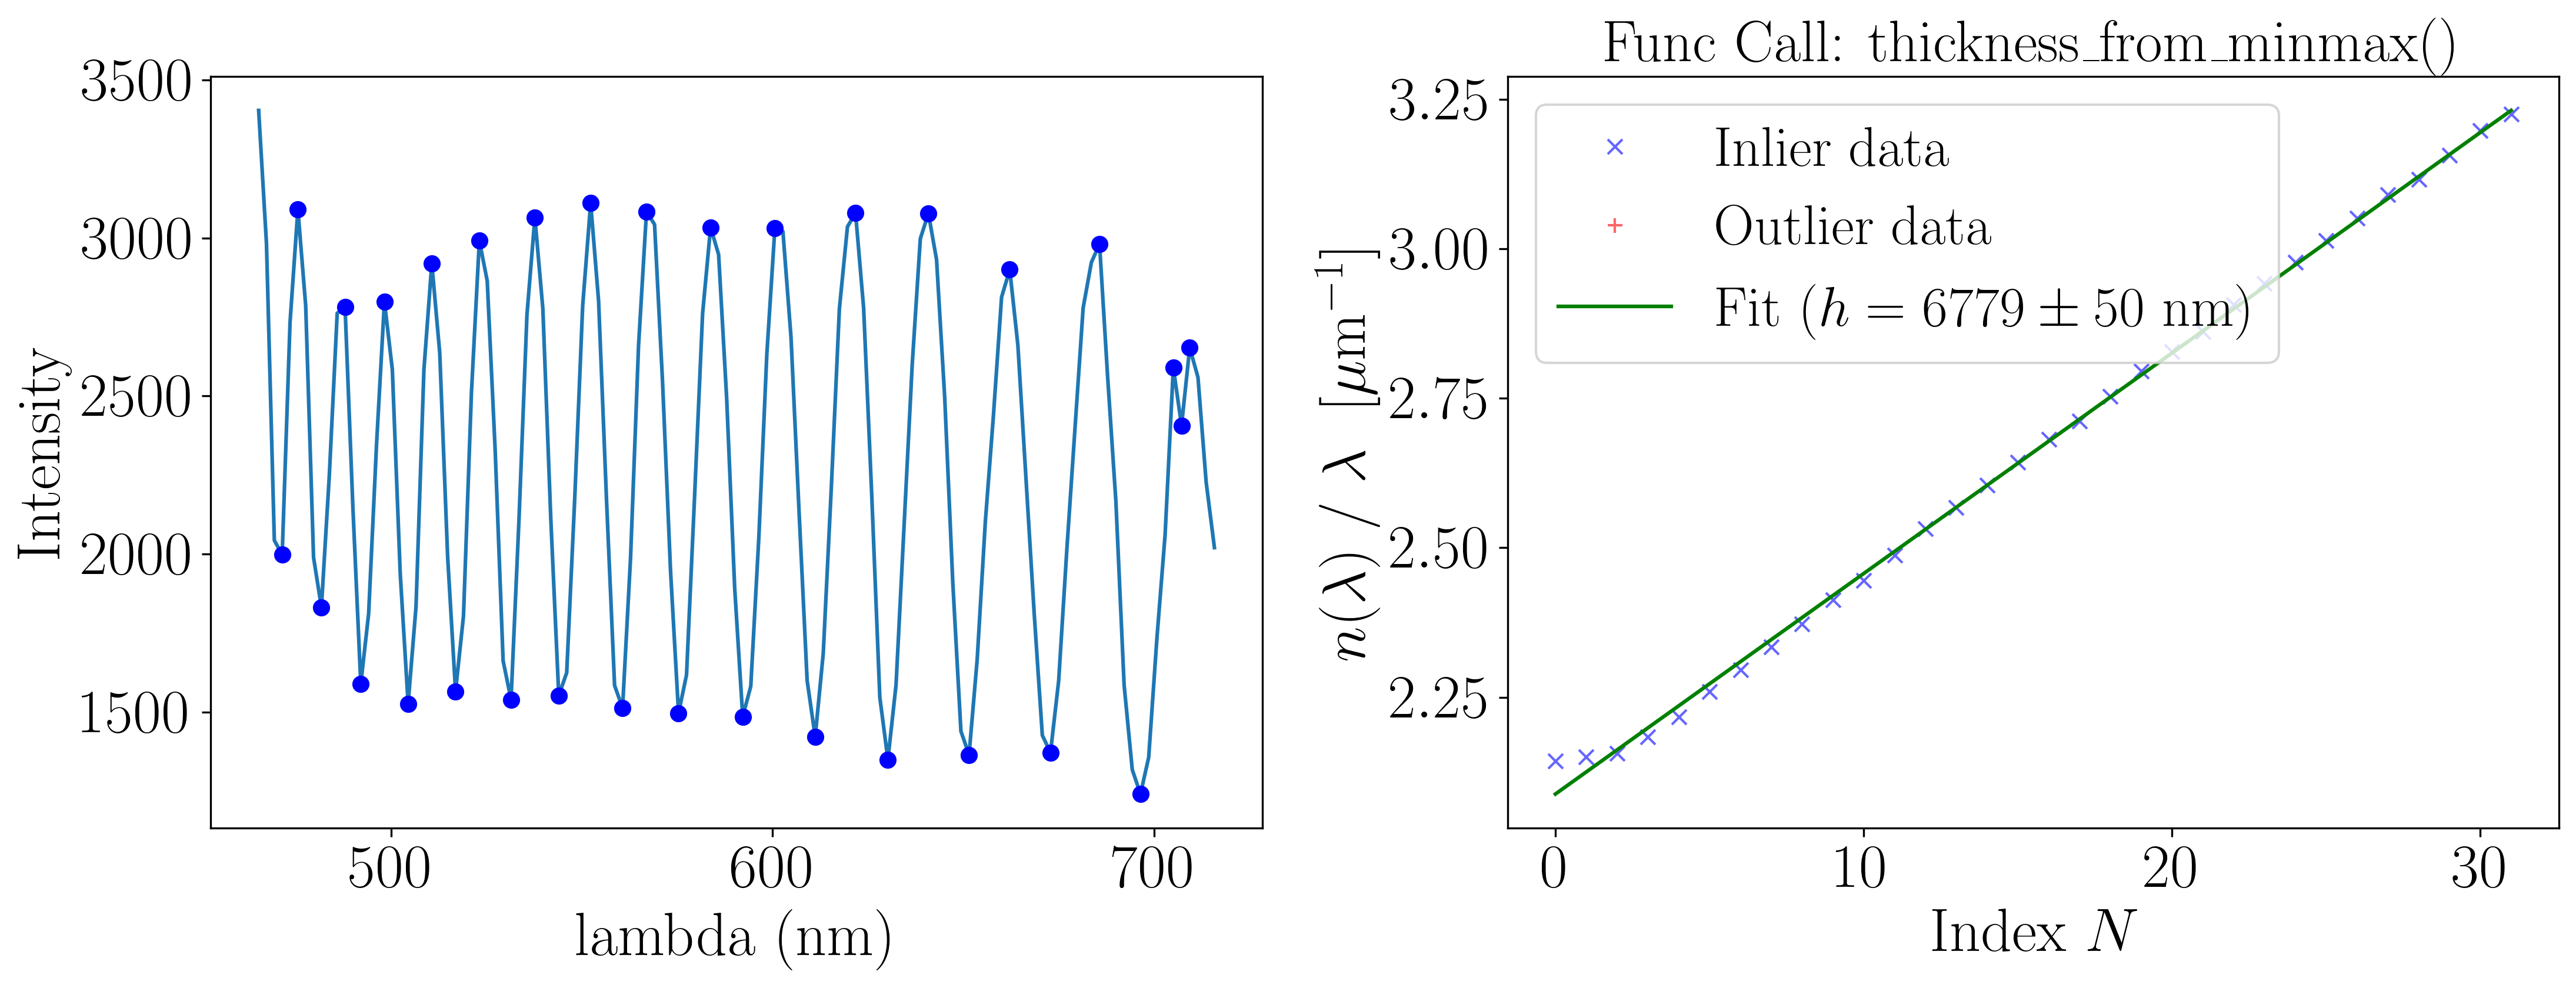

épaisseur = 6778.529516923534 nm


In [9]:
#choix du point
i_espace = 30 #sample
i_temps  = 0 #line
window = None

# calculer l'épaisseur en un point
[datacube,n_temps,n_espace,n_lambdas,v_temps,v_espace,v_lambdas] = get_datacube(file_bil)
gauche = 40 #pour crop en lambdas
droite = 160
v_lambdas = v_lambdas[gauche:droite]
datacube = datacube[:,:,gauche:droite]

if window != None:
    datacube = savgol_filter(datacube,window,3)

epaisseur,prop_outliers = calcul(datacube,v_lambdas,prominence,distance,i_temps,i_espace,prop_max_outliers,1,n)
print('épaisseur =',epaisseur,'nm')

On utilise le module optifik qui détecte les minima et maxima du spectre (figure de gauche).
Optifik fait une régression linéaire faisant intervenir les valeurs des longueurs d'ondes où sont atteints ces extrema. La valeur de l'épaisseur du film est contenue dans la pente de cette régression linéaire.
On obtient que l'épaisseur du film vaut 7 micromètres.